In [1]:
!pip install miRBench biopython


In [23]:

"""
Encodes each miRNA-target site pair in a TSV with reverse-complement miRNA k-mer count features from the gene sequence, for k = 2 to 12.

Usage:
    python encode.py --input_dataset <INPUT_TSV> --output_encoded_dataset <OUTPUT_TSV>

Arguments:
    --input_dataset           Path to input dataset (TSV)
    --output_encoded_dataset  Output path for encoded dataset with k-mer features (TSV)
"""

from Bio.Seq import Seq
import pandas as pd
import os
from miRBench.dataset import get_dataset_df

dataset=get_dataset_df('AGO2_CLASH_Hejret2023', split="train")[['gene', 'noncodingRNA', 'label']]

MIRNA_LENGTH = 20
K_MIN = 2
K_MAX = 12

def reverse_complement(seq):
    """Return the reverse complement of a nucleotide sequence using Biopython."""
    seq_obj = Seq(seq)
    return str(seq_obj.reverse_complement())

def truncate_or_pad(seq, desired_length=MIRNA_LENGTH):
    """
    Truncate the sequence if it's longer than the desired length,
    or pad it with 'N' if it's shorter.
    """
    return seq[:desired_length] if len(seq) > desired_length else seq.ljust(desired_length, 'N')

def count_kmers(miRNA, gene, k):
    """
    For a given k, compute a dictionary of counts for each k-mer's reverse complement
    in the gene. The keys are formatted as 'pos<position>_k<k>'.
    """
    counts = {}
    for i in range(len(miRNA) - k + 1):
        kmer = miRNA[i:i+k]
        rev = reverse_complement(kmer)
        counts[f'pos{i+1}_k{k}'] = gene.count(rev)
    return counts

def process_dataset(dataset, sep=',', chunk_size=10000):
    """
    Reads a TSV file in chunks and extracts features based on the count of reverse complement k-mers
    from the miRNA present in the corresponding gene sequence.
    Returns a DataFrame with the original 'noncodingRNA', 'gene', 'label' columns
    followed by the k-mer count features.
    """
    rows = []
    for chunk in pd.read_csv(dataset, sep=sep, chunksize=chunk_size):
        for _, row in chunk.iterrows():
            # Prepare the feature dictionary with the original columns.
            features = {
                'noncodingRNA': row['noncodingRNA'],
                'gene': row['gene'],
                'label': row['label']
            }
            miRNA = truncate_or_pad(str(row['noncodingRNA']))
            gene = str(row['gene']).upper()
            # Compute k-mer counts for each k between K_MIN and K_MAX.
            for k in range(K_MIN, K_MAX + 1):
                kmers = count_kmers(miRNA, gene, k)
                features.update(kmers)
            rows.append(features)
    df = pd.DataFrame(rows)
    return df

dataset.to_csv("AGO2_CLASH_Hejret2023_train.csv", index=False)
df_encoded = process_dataset("AGO2_CLASH_Hejret2023_train.csv", sep=',')
df_encoded.to_csv("AGO2_CLASH_Hejret2023_train_encoded.tsv", sep='\t', index=False)
df_encoded.head()

Using cached dataset /root/.miRBench/datasets/20540907/AGO2_CLASH_Hejret2023/train/dataset.tsv


,noncodingRNA,gene,label,pos1_k2,pos2_k2,pos3_k2,pos4_k2,pos5_k2,pos6_k2,pos7_k2,...,pos10_k11,pos1_k12,pos2_k12,pos3_k12,pos4_k12,pos5_k12,pos6_k12,pos7_k12,pos8_k12,pos9_k12
0,TGAGGGCTCCAGGTGACGGTGG,CAGCCTCCAGCCAAGCCCAGCTCACCGTCATTGCTTGCTCTCCTCC...,1,7,6,6,7,7,6,5,...,0,0,0,0,0,0,0,0,0,0
1,TGAGGGCTCCAGGTGACGGTGG,AAAATATCCATTTATACTATGTACCTGGTGACCAGTGTCTCTCATT...,0,3,4,4,3,3,0,1,...,0,0,0,0,0,0,0,0,0,0
2,AAAGCAAATGTTGGGTGAACGGC,TGTTTCCTCTTATTCAAGCCATGCACCCTACTCTTGCTGGTAAAAT...,1,4,4,7,3,4,4,4,...,0,0,0,0,0,0,0,0,0,0
3,AAAGCAAATGTTGGGTGAACGGC,TCAGGAACCTTTGACTGCTTCCATGTTGGCATCTGCCCCTCCTCAA...,1,3,3,6,4,5,3,3,...,0,0,0,0,0,0,0,0,0,0
4,AAAGCAAATGTTGGGTGAACGGC,ACGGCTGTTTCCTCTTATTCAAGCTATGCACCCTACTCTTGCTGGT...,1,4,4,8,4,4,4,4,...,0,0,0,0,0,0,0,0,0,0


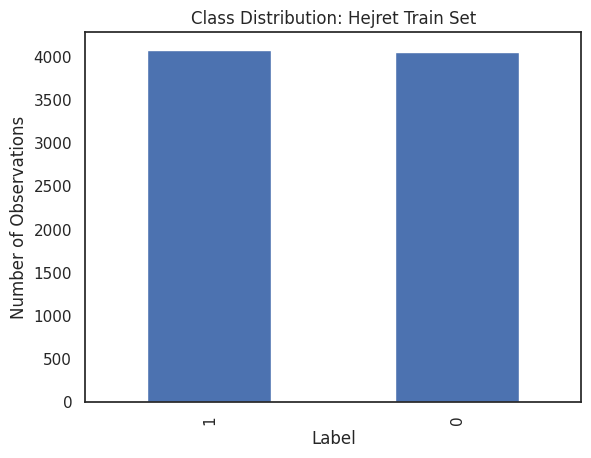

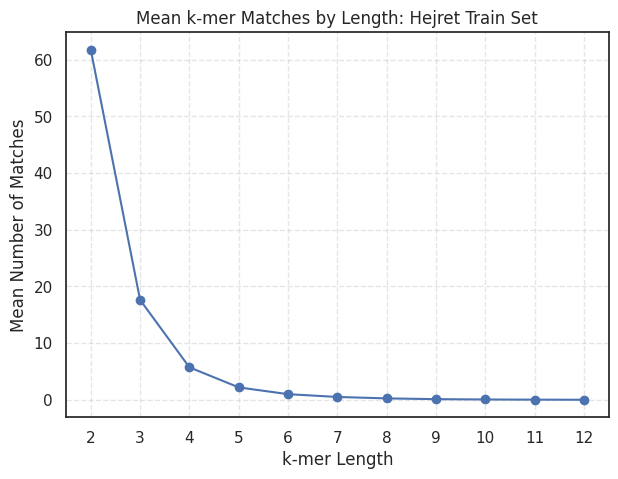

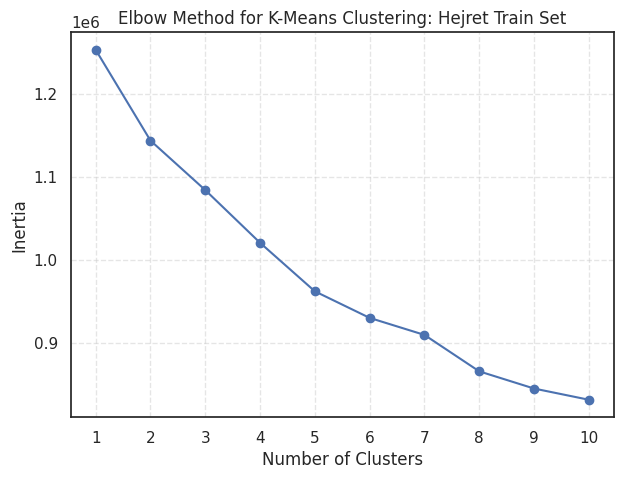

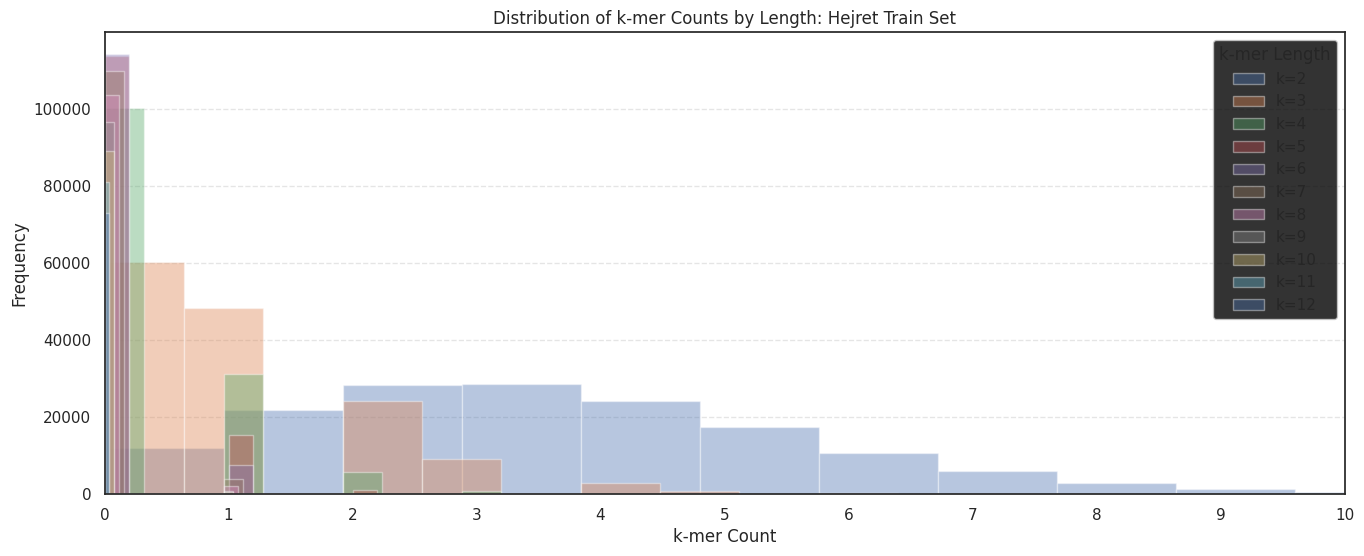

In [25]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Class distribution (label 0 vs label 1)
df_encoded["label"].value_counts().plot(kind="bar")
plt.xlabel("Label")
plt.ylabel("Number of Observations")
plt.title("Class Distribution: Hejret Train Set")
plt.show()

# Mean k-mer matches by length
kmer_totals = {}
for k in range(2, 13):
    cols = [c for c in df_encoded.columns if c.endswith(f"_k{k}")]
    kmer_totals[k] = df_encoded[cols].sum(axis=1).mean()

plt.figure(figsize=(7, 5))
plt.plot(list(kmer_totals.keys()), list(kmer_totals.values()),marker="o")
plt.xlabel("k-mer Length")
plt.ylabel("Mean Number of Matches")
plt.title("Mean k-mer Matches by Length: Hejret Train Set")
plt.xticks(range(2, 13))
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

#K-means: Elbow method
feature_cols = [c for c in df_encoded.columns if c.startswith("pos")]
X = df_encoded[feature_cols]
inertias = []
data = StandardScaler().fit_transform(X)

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(data)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(range(1, 11), inertias, marker="o")
plt.title("Elbow Method for K-Means Clustering: Hejret Train Set")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.xticks(range(1, 11))
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

#Count distribution: K-mer grouping
plt.figure(figsize=(16, 6))

for k in range(2, 13):
    cols = [c for c in df_encoded.columns if c.endswith(f"_k{k}")]
    counts = df_encoded[cols].to_numpy().flatten()

    plt.hist(counts, bins=25, alpha=0.4, label=f"k={k}")

plt.title("Distribution of k-mer Counts by Length: Hejret Train Set")
plt.xlabel("k-mer Count")
plt.ylabel("Frequency")
plt.xlim(0, 5)
plt.xticks(range(0, 11))
plt.legend(title="k-mer Length")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = df_encoded.drop(columns=['noncodingRNA', 'gene', 'label'])
y = df_encoded['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=23)

clf = LogisticRegression(max_iter=10000, random_state=0)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred) * 100

print(f"Logistic Regression model accuracy: {acc:.2f}%\n")

Logistic Regression model accuracy: 78.07%



In [27]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

tree = DecisionTreeClassifier(max_depth=5)
cv_scores_tree = cross_val_score(tree, X, y, cv=3)
print("Decision Tree:")
print("Scores for each of the 3 folds:", cv_scores_tree)
print(f"Average 3-Fold Accuracy: {cv_scores_tree.mean():.4f}\n")

forest = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
cv_scores_forest = cross_val_score(forest, X, y, cv=3)
print("Random Forest:")
print("Scores for each of the 3 folds:", cv_scores_forest)
print(f"Average 3-Fold Accuracy: {cv_scores_forest.mean():.4f}\n")

gb = GradientBoostingClassifier(n_estimators=100, learning_rate=1.0, max_depth=1, random_state=42)
cv_scores_gb = cross_val_score(gb, X, y, cv=3)
print("Gradient Boosting:")
print("Scores for each of the 3 folds:", cv_scores_gb)
print(f"Average 3-Fold Accuracy: {cv_scores_gb.mean():.4f}\n")


Decision Tree:
Scores for each of the 3 folds: [0.70670597 0.73276815 0.71249539]
Average 3-Fold Accuracy: 0.7173

Random Forest:
Scores for each of the 3 folds: [0.72955048 0.76409878 0.74640619]
Average 3-Fold Accuracy: 0.7467

Gradient Boosting:
Scores for each of the 3 folds: [0.72991894 0.77626244 0.74530041]
Average 3-Fold Accuracy: 0.7505



In [28]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)
print("Decision Tree:")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree), "\n")

forest = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
forest.fit(X_train, y_train)
y_pred_forest = forest.predict(X_test)
print("Random Forest:")
print("Accuracy:", accuracy_score(y_test, y_pred_forest))
print(classification_report(y_test, y_pred_forest), "\n")

gb = GradientBoostingClassifier(n_estimators=100, learning_rate=1.0, max_depth=1, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
print("Gradient Boosting:")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb), "\n")


Decision Tree:
Accuracy: 0.7407862407862408
              precision    recall  f1-score   support

           0       0.69      0.88      0.77       816
           1       0.83      0.60      0.70       812

    accuracy                           0.74      1628
   macro avg       0.76      0.74      0.74      1628
weighted avg       0.76      0.74      0.74      1628
 

Random Forest:
Accuracy: 0.7628992628992629
              precision    recall  f1-score   support

           0       0.71      0.88      0.79       816
           1       0.85      0.64      0.73       812

    accuracy                           0.76      1628
   macro avg       0.78      0.76      0.76      1628
weighted avg       0.78      0.76      0.76      1628
 

Gradient Boosting:
Accuracy: 0.7813267813267813
              precision    recall  f1-score   support

           0       0.76      0.82      0.79       816
           1       0.81      0.74      0.77       812

    accuracy                           0.7

In [29]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, average_precision_score
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

precision = precision_score(y_test, y_pred, average='weighted')
print("Precision:", precision)

aps = average_precision_score(y_test, y_pred, average='weighted')
print("APS:", aps)

recall = recall_score(y_test, y_pred, average='weighted')
print("Recall:", recall)

f1 = f1_score(y_test, y_pred, average='weighted')
print("F1-Score:", f1)

Confusion Matrix:
 [[699 117]
 [240 572]]
Precision: 0.7871934319580349
APS: 0.7322328623564799
Recall: 0.7807125307125307
F1-Score: 0.7794121670204281


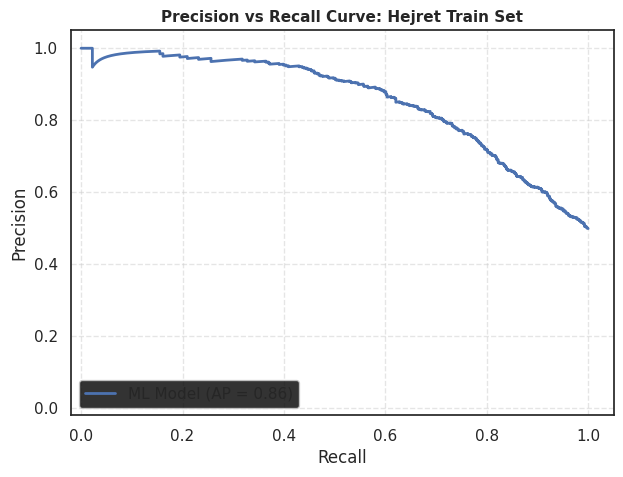

In [30]:
from sklearn.metrics import precision_recall_curve, average_precision_score

y_scores = forest.predict_proba(X_test)[:, 1]
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_scores)
ap_score = average_precision_score(y_test, y_scores)

plt.figure(figsize=(7, 5))
plt.plot(recall_curve, precision_curve, linewidth=2,
         label=f"ML Model (AP = {ap_score:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision vs Recall Curve: Hejret Train Set", fontsize=11, fontweight='bold')
plt.xlim([-0.02, 1.05])
plt.ylim([-0.02, 1.05])
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="lower left")
plt.show()